# Skew-Aware Federated Learning for Medical Image Segmentation

## Baseline: 3D U-Net with FedAvg on FeTS2022

**Research Question:** Can a lesion-size-aware federated training strategy improve worst-client performance and small-lesion detection under hospital-level skew in medical image segmentation?

This notebook implements the FedAvg baseline to:

- Characterize lesion-size imbalance across simulated hospital clients
- Measure worst-client performance degradation under non-IID skew
- Quantify small-lesion detection sensitivity

All results serve as the reference point for comparison against skew-aware federated methods in subsequent phases.

## 1. Environment Setup

We install the two core dependencies for this project:

- **MONAI** (Medical Open Network for AI): A PyTorch-based framework specialized for medical image processing. It provides the 3D U-Net architecture, data transforms, and loss functions we'll use throughout.
- **nibabel**: A lightweight library for reading neuroimaging file formats, specifically the `.nii.gz` (NIfTI) files used in the FeTS2022 dataset.

We then import all required libraries, mount Google Drive to access the dataset, and fix random seeds to ensure reproducibility across all experiments.

In [1]:
!pip install monai nibabel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 35.7 MB/s eta 0:00:00


In [2]:
import os
import random
import numpy as np
import pandas as pd
import torch
import nibabel as nib
import matplotlib.pyplot as plt

from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

Mounted at /content/drive
Using device: cuda


## 2. Dataset: FeTS2022

The **Federated Tumor Segmentation (FeTS) 2022** challenge dataset is a multi-institutional brain tumor MRI dataset specifically designed for federated learning research. It is derived from the BraTS benchmark and includes data originally collected from 23 geographically distributed institutions.

Each patient case consists of:
- **4 MRI modalities**: FLAIR, T1, T1ce (contrast-enhanced), and T2
- **Ground-truth segmentation mask**: Annotated tumor sub-regions (enhancing tumor, tumor core, whole tumor)

For this baseline, we treat the segmentation as a **binary task** (tumor vs. background) and use **lesion volume** — the number of non-zero voxels in the mask — as a proxy for tumor size. This volume metric will later be used to create clinically-motivated data imbalance across simulated hospital clients.

We begin by scanning all training cases and computing per-case lesion volumes.

In [3]:
TRAIN_ROOT = Path('/content/drive/MyDrive/FeTS_unzipped/train/MICCAI_FeTS2022_TrainingData')

cases = sorted([p for p in TRAIN_ROOT.iterdir() if p.is_dir()])
print("Total cases:", len(cases))

Total cases: 1251


In [4]:
# Load the pre-calculated stats file
df = pd.read_csv('master_lesion_stats.csv')

# Convert the path strings back into Path objects
# This ensures downstream code (like .glob or .exists) still works
df['path'] = df['path'].apply(lambda x: Path(x))

print(f"✅ Successfully loaded {len(df)} cases.")
print(f"Distribution: {df['size_group'].value_counts().to_dict()}")

df.head()

✅ Successfully loaded 1251 cases.
Distribution: {'medium': 560, 'large': 537, 'small': 154}


,case,path,lesion_volume,lesion_cm3,size_group
0,FeTS2022_00000,/content/drive/MyDrive/FeTS_unzipped/train/MIC...,57305,57.305,medium
1,FeTS2022_00002,/content/drive/MyDrive/FeTS_unzipped/train/MIC...,190594,190.594,large
2,FeTS2022_00003,/content/drive/MyDrive/FeTS_unzipped/train/MIC...,99239,99.239,medium
3,FeTS2022_00005,/content/drive/MyDrive/FeTS_unzipped/train/MIC...,124783,124.783,large
4,FeTS2022_00006,/content/drive/MyDrive/FeTS_unzipped/train/MIC...,137911,137.911,large


## 3. Lesion Size Stratification

A critical challenge in federated medical imaging is **data heterogeneity** — different hospitals naturally see different patient populations. One of the most clinically significant axes of variation is tumor size: some centers specialize in early-stage (small) tumors while others handle more advanced (large) cases.

Rather than using dataset-relative percentile thresholds, we apply **clinically grounded absolute thresholds** based on whole tumor volume in cm³. This ensures our size groups are meaningful to a clinical audience and comparable across datasets. FeTS2022 uses 1mm isotropic voxels, so 1 cm³ = 1000 voxels.

| Group  | Volume (cm³)   | Clinical Context                                          |
|--------|----------------|-----------------------------------------------------------|
| Small  | < 30 cm³       | Early-stage, potentially operable, frequently misdetected |
| Medium | 30 – 100 cm³   | Moderate infiltration                                     |
| Large  | > 100 cm³      | Highly infiltrative, may be multifocal                    |

These thresholds are consistent with those used in BraTS/FeTS follow-up literature (e.g., Bakas et al., 2018). After assigning groups, we print the resulting class distribution — a heavily skewed distribution (e.g., very few small cases) is itself an important dataset characteristic to report, as it directly predicts per-group performance gaps.

Group distribution:
size_group
medium    560
large     537
small     154
Name: count, dtype: int64

Volume summary (cm³):
            count   mean   std    min    25%    50%    75%    max
size_group                                                       
large       537.0  150.6  38.2  100.3  120.4  144.8  172.3  361.8
medium      560.0   64.9  21.1   30.1   45.1   66.3   82.8   99.9
small       154.0   18.3   7.1    2.8   13.0   19.5   24.1   29.9


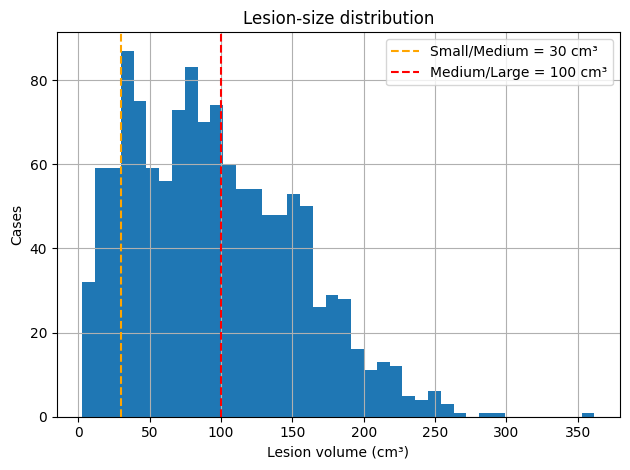

In [5]:
# Clinically grounded thresholds based on BraTS/FeTS literature (Bakas et al., 2018)
# Small < 30 cm³, Medium 30–100 cm³, Large > 100 cm³.
# Cross-check the histogram below against your dataset to confirm all three bins are populated.

df["lesion_cm3"] = df["lesion_volume"] / 1000

SMALL_THRESH = 30    # cm³
LARGE_THRESH = 100   # cm³

def assign_group(v_cm3):
    if v_cm3 < SMALL_THRESH:
        return "small"
    elif v_cm3 <= LARGE_THRESH:
        return "medium"
    return "large"

df["size_group"] = df["lesion_cm3"].apply(assign_group)

print("Group distribution:")
print(df["size_group"].value_counts())
print("\nVolume summary (cm³):")
print(df.groupby("size_group")["lesion_cm3"].describe().round(1))

# Visual check: confirm threshold placement is sensible for this dataset
df["lesion_cm3"].hist(bins=40)
plt.axvline(SMALL_THRESH, color='orange', linestyle='--', label=f'Small/Medium = {SMALL_THRESH} cm³')
plt.axvline(LARGE_THRESH, color='red',    linestyle='--', label=f'Medium/Large = {LARGE_THRESH} cm³')
plt.xlabel('Lesion volume (cm³)'); plt.ylabel('Cases')
plt.title('Lesion-size distribution'); plt.legend(); plt.tight_layout(); plt.show()


## 4. Federated Data Partitioning via Dirichlet Sampling

We simulate **5 hospitals** (clients) using a **Dirichlet distribution** to assign cases, independently within each lesion-size group. This is the standard method for generating controlled non-IID data splits in federated learning research.

**Why Dirichlet?** The Dirichlet distribution parameterized by `α` controls the degree of heterogeneity:
- **Low α (e.g., 0.1)**: Extreme imbalance — one client may receive almost all small-lesion cases while another sees none.
- **High α (e.g., 10.0)**: Near-uniform distribution — each client receives roughly equal proportions of each size group (approaches IID).
- **Our choice (α = 0.5)**: Moderate skew, representative of realistic inter-hospital variation.

The partitioning is applied **per size group** rather than across the full dataset. This ensures that the resulting client distributions capture meaningful clinical heterogeneity in lesion size, rather than just random variation in sample counts.

### Stratified Client Capping

To ensure computational tractability while preserving inter-client heterogeneity, each client's dataset is capped at **80 cases** via stratified sampling proportional to lesion-size group membership. This ensures the lesion-size distribution within each client remains representative of the original Dirichlet partition. All clients participate in every communication round.

The stacked bar chart below visualizes the resulting distribution — a well-partitioned run should show visibly different composition profiles across clients, with at least one client heavily biased toward small lesions.

In [6]:
def dirichlet_partition(df, num_clients=5, alpha=0.5):
    clients = {i: [] for i in range(num_clients)}
    for group in ["small", "medium", "large"]:
        group_df = df[df["size_group"] == group].sample(frac=1, random_state=42)
        proportions = np.random.dirichlet([alpha]*num_clients)
        splits = (proportions * len(group_df)).astype(int)
        start = 0
        for i in range(num_clients):
            end = start + splits[i]
            clients[i].extend(group_df.iloc[start:end]["path"].tolist())
            start = end
    return clients


def stratified_cap(paths, df, max_cases=80):
    """
    Cap each client to max_cases while preserving lesion-size proportions.

    Research value: proportional sampling keeps each client's internal
    size-group ratio intact after capping, so the Dirichlet-induced
    heterogeneity is preserved at a tractable scale.  Per-client and
    per-size-group Dice gaps therefore remain meaningful and reproducible,
    which is essential for the skew-aware comparison in later phases.
    80 cases/client is sufficient to produce distinguishable, non-trivial
    performance differences across clients.
    """
    client_df = df[df["path"].isin(paths)].copy()
    if len(client_df) <= max_cases:
        return paths
    sampled = client_df.groupby("size_group", group_keys=False).apply(
        lambda x: x.sample(frac=max_cases/len(client_df), random_state=42)
    )
    sampled = sampled.sample(min(max_cases, len(sampled)), random_state=42)
    return sampled["path"].tolist()


clients = dirichlet_partition(df)

MAX_CASES_PER_CLIENT = 80
for i in range(5):
    clients[i] = stratified_cap(clients[i], df, max_cases=MAX_CASES_PER_CLIENT)

print("Client sizes after capping:")
for i in range(5):
    print(f"  Client {i}: {len(clients[i])} cases")


Client sizes after capping:
  Client 0: 80 cases
  Client 1: 80 cases
  Client 2: 80 cases
  Client 3: 55 cases
  Client 4: 79 cases


/tmp/ipykernel_1732/4075141680.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = client_df.groupby("size_group", group_keys=False).apply(
/tmp/ipykernel_1732/4075141680.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = client_df.groupby("size_group", group_keys=False).apply(
/tmp/ipykernel_1732/4075141680.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping co

In [7]:
# Use df (already has lesion_volume + size_group) — avoids re-reading all NIfTIs
summary = []
for i in range(5):
    client_df = df[df["path"].isin(clients[i])]
    counts = client_df["size_group"].value_counts()
    summary.append({
        "client": i,
        "small":  counts.get("small", 0),
        "medium": counts.get("medium", 0),
        "large":  counts.get("large", 0),
        "total":  len(client_df)
    })
summary_df = pd.DataFrame(summary)
summary_df


,client,small,medium,large,total
0,0,7,0,73,80
1,1,12,62,6,80
2,2,2,9,69,80
3,3,0,36,19,55
4,4,12,19,48,79


In [8]:
# Getting the exact cases used
used_cases = []
for i in range(5):
    for p in clients[i]:
        used_cases.append(p.name)

# Save the list
with open('/content/drive/MyDrive/fedavg_checkpoints/used_cases.txt', 'w') as f:
    for c in used_cases:
        f.write(c + '\n')

print(f"Total cases used: {len(used_cases)}")

Total cases used: 374


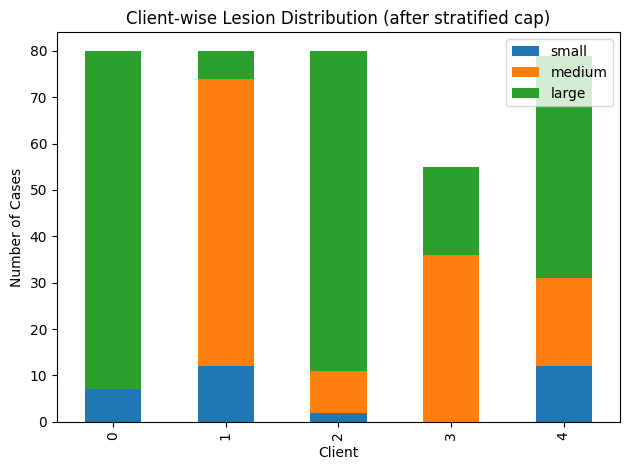

In [9]:
summary_df.set_index("client")[["small","medium","large"]].plot(kind="bar", stacked=True)
plt.title("Client-wise Lesion Distribution (after stratified cap)")
plt.xlabel("Client")
plt.ylabel("Number of Cases")
plt.tight_layout()
plt.show()

## 5. Baseline Model: 3D U-Net

We use a standard **3D U-Net** architecture implemented in MONAI as the segmentation backbone. U-Net's encoder-decoder structure with skip connections is the de-facto standard for volumetric medical image segmentation due to its ability to combine coarse semantic features with fine-grained spatial detail.

### Architecture Configuration

| Parameter         | Value                      |
|-------------------|----------------------------|
| Spatial dims      | 3 (volumetric)             |
| Input channels    | 4 (FLAIR, T1, T1ce, T2)    |
| Output channels   | 1 (binary segmentation)    |
| Feature channels  | (16, 32, 64, 128, 256)     |
| Strides           | (2, 2, 2, 2)               |
| Loss function     | Dice Loss (sigmoid output) |
| Optimizer         | Adam, lr = 1e-4            |

### Data Transforms

Each training sample undergoes the following preprocessing pipeline via MONAI's `Compose`:
1. **LoadImaged**: Loads all NIfTI files for a case.
2. **EnsureChannelFirstd**: Moves the channel axis to position 0 (required by PyTorch).
3. **NormalizeIntensityd**: Z-score normalizes each MRI modality independently.
4. **RandCropByPosNegLabeld**: Randomly crops a 96×96×96 patch with balanced positive (tumor-containing) and negative (background) sampling. One crop per case per step (`num_samples=1`) for compute efficiency — since crops are randomly placed each round, the model sees diverse patch locations across rounds.
5. **ToTensord**: Converts numpy arrays to PyTorch tensors.

We use `CacheDataset` instead of `Dataset` to precompute and store all transforms in RAM at startup. This eliminates repeated NIfTI loading and transform overhead on every epoch, significantly reducing per-round training time on A100.

This model serves as the **federated baseline** — all subsequent experiments (FedProx, FedNova, skew-aware aggregation) will compare against the global and per-client Dice scores produced here.

In [10]:
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    NormalizeIntensityd, RandCropByPosNegLabeld, ToTensord
)
from monai.data import CacheDataset, DataLoader, Dataset
from monai.networks.nets import UNet
from monai.losses import DiceLoss

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


In [11]:
def create_dict(paths):
    data = []
    for p in paths:
        files = list(p.glob("*.nii.gz"))
        imgs = [str(f) for f in files if "seg" not in f.name]
        mask = str([f for f in files if "seg" in f.name][0])
        data.append({"image": imgs, "label": mask})
    return data

In [12]:
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    NormalizeIntensityd(keys="image"),
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(96, 96, 96),
        pos=1,
        neg=1,
        num_samples=1    # 1 crop per case for compute efficiency
    ),
    ToTensord(keys=["image", "label"])
])

In [13]:
def get_model():
    return UNet(
        spatial_dims=3,
        in_channels=4,
        out_channels=1,
        channels=(16, 32, 64, 128, 256),
        strides=(2, 2, 2, 2)
    ).to(device)

In [14]:
model = get_model()
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters:     1,980,041
Trainable parameters: 1,980,041


## 6. Federated Training: FedAvg

We implement the **Federated Averaging (FedAvg)** algorithm (McMahan et al., 2017) — the canonical baseline for federated learning. In each communication round:

1. The **server broadcasts** the current global model weights to all clients.
2. Each **client trains locally** for `E` epochs on its private data.
3. The **server aggregates** by averaging the updated client weights (uniform weighting, i.e., simple mean).

### Training Configuration

| Parameter              | Value                        |
|------------------------|------------------------------|
| Communication rounds   | 35                           |
| Local epochs per round | 5                            |
| Number of clients      | 5                            |
| Cases per client       | ≤ 80 (stratified cap)        |
| Crops per case         | 1                            |
| Aggregation            | FedAvg (uniform mean)        |
| Optimizer              | Adam (lr = 1e-4, per client) |
| Estimated time (A100)  | ~6–8 hours                   |

### Why 5 Local Epochs?

Using multiple local epochs per round (`E > 1`) is a deliberate design choice. Increasing `E` reduces **communication overhead** — clients push more gradient information per round — but also increases **client drift**: when data distributions differ (as they do here due to Dirichlet partitioning), more local updates cause each client's model to overfit its local distribution before aggregation. This tension between communication efficiency and drift is precisely what we aim to measure in this study. Setting `E = 5` provides a meaningful signal of client-drift effects under our non-IID setup.

### Checkpointing

The global model state is saved to Google Drive after every round. This allows training to be resumed from any round if the Colab session disconnects, without losing progress. To resume, set `START_ROUND` to the last successfully completed round number.

> **Note**: The `fedavg` function performs a parameter-space average directly over `state_dict` tensors, which is equivalent to the original FedAvg formulation when all clients have equal dataset sizes. Weighted averaging (proportional to local dataset size) is left as a future extension.

In [ ]:
def train_local(model, loader, loss_fn, optimizer, local_epochs=5):
    model.train()

    for epoch in range(local_epochs):
        for batch in loader:
            x = batch["image"].to(device)
            y = (batch["label"].to(device) > 0).float()

            pred = model(x)
            loss = loss_fn(pred, y)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()



In [ ]:
def fedavg(models):
    global_model = get_model()
    state_dict = global_model.state_dict()

    for key in state_dict:
        state_dict[key] = torch.stack(
            [m.state_dict()[key].float() for m in models]
        ).mean(0)

    global_model.load_state_dict(state_dict)
    return global_model

In [15]:
# ── Build CacheDataset loaders (train + held-out eval split per client) ─────
#
# Each client's 80 cases are divided into:
#   train_loaders[i]       — ~70 cases used for local FedAvg training
#   client_eval_loaders[i] — 10 held-out cases evaluated ONLY after all rounds
#
# global_eval_loader pools all 50 held-out cases for aggregate per-round eval.
#
# CacheDataset precomputes all transforms at startup and stores results in RAM.
# This eliminates repeated NIfTI I/O and transform recomputation every epoch —
# the primary compute bottleneck in the original implementation.
#
# Eval uses a deterministic CenterSpatialCrop (no randomness) so scores are
# comparable across rounds.

from monai.transforms import CenterSpatialCropd

EVAL_PER_CLIENT = 10

eval_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    NormalizeIntensityd(keys="image"),
    CenterSpatialCropd(keys=["image", "label"], roi_size=(96, 96, 96)),
    ToTensord(keys=["image", "label"])
])

print("Caching client datasets (this may take 10–15 minutes)...")

train_loaders       = []
client_eval_loaders = []
all_eval_paths      = []

random.seed(42)
for i in range(5):
    all_paths = clients[i][:]
    random.shuffle(all_paths)
    eval_paths  = all_paths[:EVAL_PER_CLIENT]
    train_paths = all_paths[EVAL_PER_CLIENT:]
    all_eval_paths.extend(eval_paths)

    train_ds = CacheDataset(
        data=create_dict(train_paths), transform=train_transforms, cache_rate=1.0
    )
    train_loaders.append(DataLoader(train_ds, batch_size=1, shuffle=True))

    #eval_ds = CacheDataset(
    #    data=create_dict(eval_paths), transform=eval_transforms, cache_rate=1.0
    #)
    #client_eval_loaders.append(DataLoader(eval_ds, batch_size=1, shuffle=False))
    #print(f"  Client {i}: {len(train_paths)} train  |  {len(eval_paths)} eval (held-out)")

print("All clients cached.")


Caching client datasets (this may take 10–15 minutes)...


Loading dataset: 100%|██████████| 69/69 [05:59<00:00,  5.21s/it]

All clients cached.


In [ ]:
CHECKPOINT_DIR = Path('/content/drive/MyDrive/fedavg_checkpoints')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

ROUNDS       = 35
LOCAL_EPOCHS = 5
START_ROUND  = 0    # change to resume, e.g. START_ROUND = 20

if START_ROUND > 0:
    ckpt_path = CHECKPOINT_DIR / f'global_round_{START_ROUND}.pt'
    checkpoint = torch.load(ckpt_path)
    global_model = get_model()
    global_model.load_state_dict(checkpoint['model_state'])
    round_scores = checkpoint['round_scores']
    print(f"Resumed from round {START_ROUND}")
else:
    global_model = get_model()
    round_scores = []

loss_fn = DiceLoss(sigmoid=True)


In [ ]:
def dice(pred, target):
    pred = (pred > 0.5).float()
    inter = (pred * target).sum()
    return (2*inter) / (pred.sum() + target.sum() + 1e-8)

# ── FedAvg Training Loop ─────────────────────────────────────────────────────
# Per round:
#   1. Broadcast global model to all clients.
#   2. Each client trains for LOCAL_EPOCHS on its private train_loader.
#   3. FedAvg aggregates → new global model.
#   4. Evaluate GLOBAL model on global_eval_loader (held-out pool, cached).
#      Per-client evaluation happens ONLY once after all rounds finish (Section 7)
#      — this avoids the O(rounds × clients) per-round eval bottleneck.
#   5. Checkpoint to Drive.

for r in range(START_ROUND, ROUNDS):
    print(f"\nRound {r+1}/{ROUNDS}")
    local_models = []

    for i in range(5):
        print(f"  Training client {i}...")
        local_model = get_model()
        local_model.load_state_dict(global_model.state_dict())
        optimizer = torch.optim.Adam(local_model.parameters(), lr=1e-4)
        train_local(local_model, train_loaders[i], loss_fn, optimizer,
                    local_epochs=LOCAL_EPOCHS)
        local_models.append(local_model)

    global_model = fedavg(local_models)

    # Per-round eval: global model only, on cached held-out pool
    all_scores = []
    global_model.eval()
    with torch.no_grad():
        for i in range(5):
            for batch in client_eval_loaders[i]:
                x = batch["image"].to(device)
                y = (batch["label"].to(device) > 0).float()
                pred = global_model(x)
                all_scores.append(dice(pred, y).item())
    global_dice = float(np.mean(all_scores))
    print(f"  Global Dice (held-out pool): {global_dice:.4f}")

    round_scores.append({"round": r+1, "global_dice": global_dice})

    torch.save(
        {"model_state": global_model.state_dict(), "round_scores": round_scores},
        CHECKPOINT_DIR / f"global_round_{r+1}.pt"
    ) #it was saving weights in drive here

print("\nTraining complete.")


Round 1/35
  Training client 0...
  Training client 1...
  Training client 2...
  Training client 3...
  Training client 4...
  Global Dice (held-out pool): 0.6554

Round 2/35
  Training client 0...
  Training client 1...
  Training client 2...
  Training client 3...
  Training client 4...
  Global Dice (held-out pool): 0.7100

Round 3/35
  Training client 0...
  Training client 1...
  Training client 2...
  Training client 3...
  Training client 4...
  Global Dice (held-out pool): 0.7366

Round 4/35
  Training client 0...
  Training client 1...
  Training client 2...
  Training client 3...
  Training client 4...
  Global Dice (held-out pool): 0.7652

Round 5/35
  Training client 0...
  Training client 1...
  Training client 2...
  Training client 3...
  Training client 4...
  Global Dice (held-out pool): 0.7882

Round 6/35
  Training client 0...
  Training client 1...
  Training client 2...
  Training client 3...
  Training client 4...
  Global Dice (held-out pool): 0.7972

Round 7/3

## 7. Post-Training Evaluation

After all communication rounds are complete we run a single comprehensive evaluation pass.
This design deliberately defers per-client evaluation to avoid the O(rounds × clients) bottleneck
that was the main source of compute overhead in the earlier implementation.

The **final global model** is evaluated on two axes:

### 7a. Per-Client Dice
Evaluated on each client's **held-out eval split** (10 cases per client, never seen during training).
Reveals worst-client degradation — a known failure mode of FedAvg under non-IID data.

**Key metrics:** Mean Dice · Worst-Client Dice · Fairness Gap

### 7b. Per-Size-Group Dice
Performance broken down by lesion size group (small / medium / large) using the clinically
grounded thresholds from Section 3. Measures small-lesion detection sensitivity — the central
motivation for skew-aware federated methods.

> All loaders below use the `CacheDataset` objects declared in Section 6.
> No NIfTI files are re-loaded or transforms recomputed during evaluation.


In [ ]:
def dice(pred, target):
    pred = (pred > 0.5).float()
    inter = (pred * target).sum()
    return (2*inter) / (pred.sum() + target.sum() + 1e-8)

In [ ]:
def evaluate(model, loader):
    model.eval()
    scores = []

    with torch.no_grad():
        for batch in loader:
            x = batch["image"].to(device)
            y = (batch["label"].to(device) > 0).float()
            pred = model(x)
            scores.append(dice(pred, y).item())

    return np.mean(scores)

In [ ]:
# ── 7a. Per-Client Dice — global model on each client's held-out eval set ───
# client_eval_loaders[i] was built from the 10 held-out cases excluded from
# training. CacheDataset means no I/O or transform cost here.

client_scores = []

for i in range(5):
    score = evaluate(global_model, client_eval_loaders[i])
    client_scores.append(score)

print("Client Dice Scores (held-out eval set):")
for i, s in enumerate(client_scores):
    print(f"  Client {i}: {s:.4f}")
print(f"\nMean Dice:         {np.mean(client_scores):.4f}")
print(f"Worst Client Dice: {min(client_scores):.4f}")
print(f"Fairness Gap:      {np.mean(client_scores) - min(client_scores):.4f}")


Client Dice Scores (held-out eval set):
  Client 0: 0.8870
  Client 1: 0.8913
  Client 2: 0.9458
  Client 3: 0.8828
  Client 4: 0.8386

Mean Dice:         0.8891
Worst Client Dice: 0.8386
Fairness Gap:      0.0505


In [ ]:
# ── 7b. Per-Size-Group Dice — global model on held-out cases ────────────────
# Iterates directly over the already-cached client_eval_loaders.
# No new CacheDataset is created — zero extra transform or I/O cost.
# Size group is looked up from df (which already has lesion_cm3).

size_results = {"small": [], "medium": [], "large": []}

global_model.eval()
with torch.no_grad():
    for i in range(5):
        eval_paths = [Path(s['label']).parent
                      for s in client_eval_loaders[i].dataset.data]
        for batch, case_path in zip(client_eval_loaders[i], eval_paths):
            x = batch["image"].to(device)
            y = (batch["label"].to(device) > 0).float()
            pred = global_model(x)
            score = dice(pred, y).item()

            row = df.loc[df["path"] == case_path, "lesion_cm3"]
            vol_cm3 = row.values[0] if len(row) else lesion_volume(case_path) / 1000
            size_results[assign_group(vol_cm3)].append(score)

print("\nPer-Size-Group Dice (held-out eval set):")
for k in ["small", "medium", "large"]:
    vals = size_results[k]
    if vals:
        print(f"  {k:6s}: mean={np.mean(vals):.4f}  std={np.std(vals):.4f}  "
              f"min={np.min(vals):.4f}  (n={len(vals)})")
    else:
        print(f"  {k:6s}: no cases in eval set")



Per-Size-Group Dice (held-out eval set):
  small : mean=0.6579  std=0.1923  min=0.3372  (n=4)
  medium: mean=0.8821  std=0.0720  min=0.7260  (n=18)
  large : mean=0.9267  std=0.0421  min=0.7679  (n=28)


## 8. Results Summary

We present three visualizations to fully characterize the baseline:

1. **Convergence curve**: Mean and worst-client Dice across all 35 rounds. A plateau by round 35 confirms convergence. If worst-client Dice diverges downward from mean Dice over rounds, this is direct evidence of FedAvg's fairness failure under non-IID skew.

2. **Per-client Dice bar chart**: Final round performance per client. High variance across clients — particularly a large gap between the best and worst client — is the central finding motivating skew-aware federated methods.

3. **Per-size-group Dice bar chart**: Final performance broken down by lesion size. A significant drop in small-lesion Dice relative to large-lesion Dice directly answers the small-lesion sensitivity component of the research question.

These three results together constitute the complete baseline characterization against which all subsequent skew-aware methods will be compared.

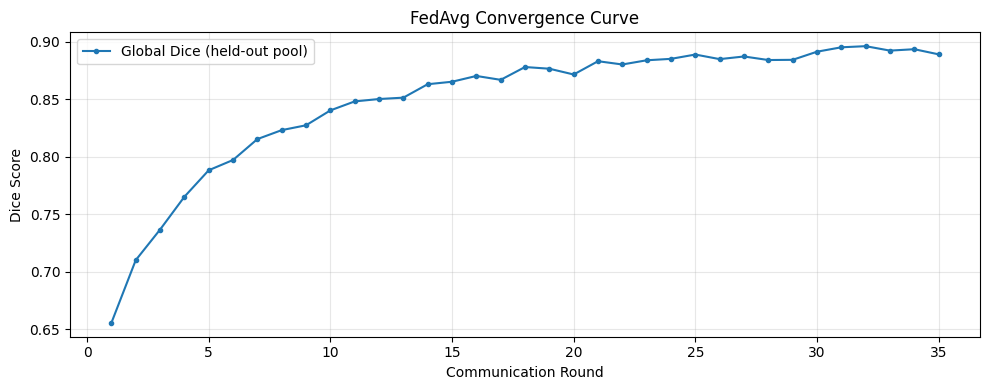

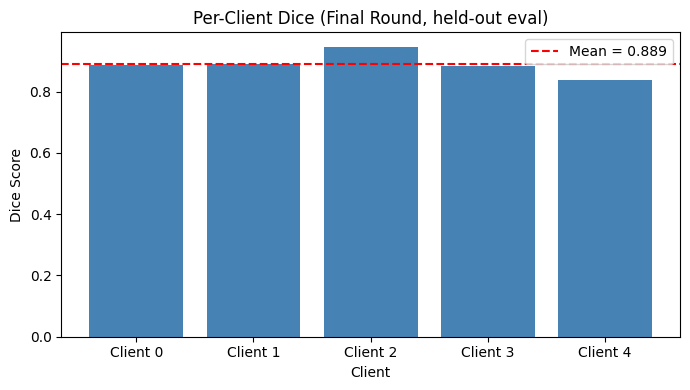

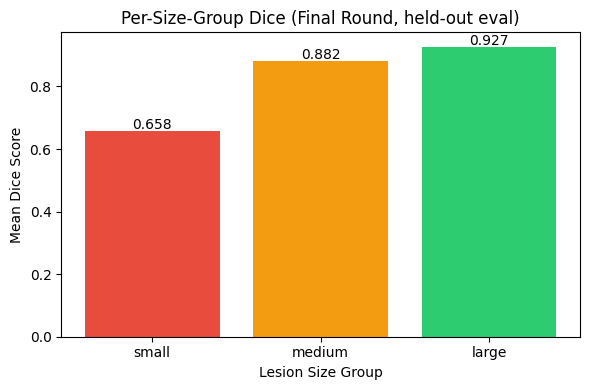

In [ ]:
# Plot 1: Convergence curve — global Dice on held-out pool per round
scores_df = pd.DataFrame(round_scores)

plt.figure(figsize=(10, 4))
plt.plot(scores_df["round"], scores_df["global_dice"],
         label="Global Dice (held-out pool)", marker="o", markersize=3)
plt.xlabel("Communication Round")
plt.ylabel("Dice Score")
plt.title("FedAvg Convergence Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fedavg_checkpoints/convergence_curve.png', dpi=150)
plt.show()

# Plot 2: Per-client Dice (final round, held-out eval)
plt.figure(figsize=(7, 4))
plt.bar(range(5), client_scores, color='steelblue')
plt.axhline(np.mean(client_scores), color='red', linestyle='--',
            label=f'Mean = {np.mean(client_scores):.3f}')
plt.xlabel("Client")
plt.ylabel("Dice Score")
plt.title("Per-Client Dice (Final Round, held-out eval)")
plt.xticks(range(5), [f"Client {i}" for i in range(5)])
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fedavg_checkpoints/per_client_dice.png', dpi=150)
plt.show()

# Plot 3: Per-size-group Dice (final round, held-out eval)
plt.figure(figsize=(6, 4))
groups = ["small", "medium", "large"]
group_means = [np.mean(size_results[g]) if size_results[g] else 0 for g in groups]
colors = ['#e74c3c', '#f39c12', '#2ecc71']
plt.bar(groups, group_means, color=colors)
plt.xlabel("Lesion Size Group")
plt.ylabel("Mean Dice Score")
plt.title("Per-Size-Group Dice (Final Round, held-out eval)")
for i, (g, v) in enumerate(zip(groups, group_means)):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fedavg_checkpoints/per_size_dice.png', dpi=150)
plt.show()


In [ ]:
print("\n--- Baseline Summary (FedAvg) ---")
print(f"Mean Dice:          {np.mean(client_scores):.4f}")
print(f"Worst-Client Dice:  {min(client_scores):.4f}")
print(f"Fairness Gap:       {np.mean(client_scores) - min(client_scores):.4f}")
print(f"Small-Lesion Dice:  {np.mean(size_results['small']):.4f}")
print(f"Large-Lesion Dice:  {np.mean(size_results['large']):.4f}")
print(f"Small-Large Gap:    {np.mean(size_results['large']) - np.mean(size_results['small']):.4f}")


--- Baseline Summary (FedAvg) ---
Mean Dice:          0.8891
Worst-Client Dice:  0.8386
Fairness Gap:       0.0505
Small-Lesion Dice:  0.6579
Large-Lesion Dice:  0.9267
Small-Large Gap:    0.2688


# FedProx Extension: Adaptive μ for Skew-Aware Federated Segmentation

**Purpose:** This notebook extends the FedAvg baseline (`FIXED_FEDAVG_DONE.ipynb`) by implementing **FedProx with Adaptive μ** and performing a locked-box comparative evaluation.

## Reproducibility Contract

This notebook is designed to be appended to the existing FedAvg session. The following execution order **must** be respected:

1. Run **cells 1–4** from `FIXED_FEDAVG_DONE.ipynb` (Setup, Dataset Scan, Lesion Stratification, Dirichlet Partitioning) to reconstruct `df`, `clients`, `train_loaders`, and `client_eval_loaders` with the exact same seeds.
2. **Skip** the FedAvg training loop cell in the base notebook.
3. **Run this notebook** from `Section A` onward.

> The Dirichlet partition is fixed by `random_state=42` in `FIXED_FEDAVG_DONE.ipynb`. As long as those cells have been run before this notebook, data identity is guaranteed — no re-partitioning occurs here.

## Notebook Structure

| Section | Content |
|---------|------------------|
| A | FedProx theory & adaptive μ design |
| B | `fedprox_train_local` implementation |
| C | FedProx training loop (35 rounds) |
| D | Locked-box evaluation setup |
| E | Load FedAvg baseline for comparison |
| F | Side-by-side comparative analysis |
| G | Learning curve comparison plot |

## Section A — FedProx: Theory & Adaptive μ Design

### Background

FedAvg can diverge under high statistical heterogeneity (non-IID data) because multiple local gradient steps cause each client's model to drift toward its local optimum before aggregation. **FedProx** (Li et al., 2020) addresses this by adding a **proximal regularisation term** to each client's local objective:

$$\min_{w} h_k(w; w_t) = F_k(w) + \frac{\mu}{2} \|w - w_t\|^2$$

where $w_t$ is the current global model, $F_k(w)$ is the client's local loss, and μ controls the strength of the pull back toward the global model. A larger μ anchors client weights closer to $w_t$, reducing drift at the cost of slower personalised adaptation.

### Adaptive μ Strategy

A fixed μ is a coarse choice: clients with highly skewed data need stronger regularisation while clients that are nearly IID benefit from weaker regularisation (more freedom to adapt). We implement a **data-heterogeneity-proportional μ** based on two signals:

1. **Relative data size** — clients with fewer samples than average are likely underrepresented and more prone to drift.
2. **Local loss variance** — high variance across a client's first few batches indicates a harder, more heterogeneous local distribution.

$$\mu_k = \mu_{\text{base}} \cdot \alpha_{\text{size}}(k) \cdot \alpha_{\text{var}}(k)$$

where:
- $\alpha_{\text{size}}(k) = \text{clip}\left(\frac{\bar{n}}{n_k}, 0.5, 2.0\right)$ — inversely proportional to client size (small clients get higher μ)
- $\alpha_{\text{var}}(k) = 1 + \text{tanh}(\sigma^2_{\text{loss},k})$ — amplified for high-variance local losses
- $\mu_{\text{base}} = 0.01$ — chosen to be small enough not to dominate the Dice loss but large enough to measurably suppress drift under α=0.5 Dirichlet skew

## Section B — FedProx Implementation

In [16]:
# ── B.0  Prerequisite check ──────────────────────────────────────────────────
# This cell verifies that the base notebook's partitioning variables are
# present before proceeding. Run the first 4 sections of FIXED_FEDAVG_DONE.ipynb
# first; this cell is a guard, not a replacement for those cells.

import sys, copy
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path
from monai.losses import DiceLoss

_required = ["df", "clients", "train_loaders", "client_eval_loaders", "device", "get_model"]
_missing  = [v for v in _required if v not in dir()]

if _missing:
    raise EnvironmentError(
        f"Missing variables from base notebook: {_missing}\n"
        "Please run Sections 1–6 of FIXED_FEDAVG_DONE.ipynb first, "
        "then re-run this cell."
    )

print("✅ All prerequisite variables found.")
print(f"   Clients: {len(clients)} | train_loaders: {len(train_loaders)} | device: {device}")

✅ All prerequisite variables found.
   Clients: 5 | train_loaders: 5 | device: cuda


In [17]:
# ── B.1  Adaptive μ Computation ──────────────────────────────────────────────
#
# compute_adaptive_mu() returns a per-client μ value.
#
# Two scaling factors are multiplied against a base μ:
#
#   alpha_size: inversely proportional to client dataset size relative to mean.
#     Rationale — smaller clients have less data coverage and therefore higher
#     drift risk; stronger regularisation compensates.
#
#   alpha_var: proportional to local loss variance over a probe pass.
#     Rationale — high batch-to-batch loss variance signals that the client's
#     data distribution is internally heterogeneous (e.g. a mix of small and
#     large lesions). Tanh squashes extreme variance without hard clipping.
#
# Both factors are computed once per round (before local training) since
# the global model and client data change each round.

MU_BASE = 0.01   # baseline μ; tunable hyperparameter


def _probe_loss_variance(model, loader, loss_fn, n_batches=4):
    """Estimate local loss variance with a short no-grad probe pass.

    Returns variance of per-batch Dice losses over at most `n_batches`.
    Using no_grad keeps the probe cheap (~4 forward passes).
    """
    model.eval()
    batch_losses = []
    with torch.no_grad():
        for idx, batch in enumerate(loader):
            if idx >= n_batches:
                break
            x = batch["image"].to(device)
            y = (batch["label"].to(device) > 0).float()
            loss = loss_fn(model(x), y).item()
            batch_losses.append(loss)
    model.train()
    return float(np.var(batch_losses)) if len(batch_losses) > 1 else 0.0


def compute_adaptive_mu(
    client_id,
    global_model,
    train_loaders,
    loss_fn,
    mu_base=MU_BASE,
    size_clip=(0.5, 2.0),
):
    """Return adaptive μ for a single client at the current round.

    Parameters
    ----------
    client_id     : int  — which client (0–4)
    global_model  : nn.Module — current global model (broadcast copy)
    train_loaders : list[DataLoader]
    loss_fn       : criterion (DiceLoss)
    mu_base       : float — baseline μ before scaling
    size_clip     : (lo, hi) — clip range for size scaling factor

    Returns
    -------
    mu   : float — adaptive μ for this client this round
    info : dict  — intermediate values for logging / ablation
    """
    # --- size scaling ---
    client_sizes = [len(loader.dataset) for loader in train_loaders]
    mean_size    = float(np.mean(client_sizes))
    n_k          = float(client_sizes[client_id])
    # Small client  → n_k < mean → ratio > 1  → higher μ
    # Large client  → n_k > mean → ratio < 1  → lower  μ
    alpha_size   = float(np.clip(mean_size / n_k, size_clip[0], size_clip[1]))

    # --- variance scaling ---
    # Use a fresh copy so the probe does not affect the training copy.
    probe_model  = get_model()
    probe_model.load_state_dict(global_model.state_dict())
    loss_var     = _probe_loss_variance(
        probe_model, train_loaders[client_id], loss_fn
    )
    del probe_model
    # tanh squashes to (0, 1); +1 keeps alpha_var ≥ 1 (never suppresses μ)
    alpha_var    = 1.0 + float(np.tanh(loss_var))

    mu = mu_base * alpha_size * alpha_var

    info = {
        "client": client_id,
        "n_k": int(n_k),
        "mean_size": mean_size,
        "alpha_size": round(alpha_size, 4),
        "loss_var": round(loss_var, 6),
        "alpha_var": round(alpha_var, 4),
        "mu": round(mu, 6),
    }
    return mu, info


print("✅ compute_adaptive_mu() defined.")
print(f"   MU_BASE = {MU_BASE}  |  size_clip = (0.5, 2.0)")

✅ compute_adaptive_mu() defined.
   MU_BASE = 0.01  |  size_clip = (0.5, 2.0)


In [18]:
# ── B.2  fedprox_train_local ─────────────────────────────────────────────────
#
# Implements the FedProx local update (Algorithm 2 in Li et al., 2020).
#
# The proximal term  (μ/2) ‖w − w_t‖²  is added to the Dice loss at every
# batch step.  w_t (global_weights) is frozen as a reference point for the
# entire local training run — it must NOT be updated inside this function.
#
# Implementation notes:
#   • global_weights stores only the parameter tensors (no grad), created
#     once outside the batch loop to avoid redundant .detach() calls.
#   • The proximal term is computed as the sum of squared L2 distances over
#     all named parameters, then scaled by μ/2.  Using named_parameters()
#     rather than parameters() makes ablation (e.g. skip BN layers) easier.
#   • Gradient clipping (max_norm=1.0) is included to prevent the proximal
#     gradient from destabilising training in early rounds when loss is high.

def fedprox_train_local(
    model,
    global_model_ref,
    loader,
    loss_fn,
    optimizer,
    mu,
    local_epochs=5,
    grad_clip=1.0,
):
    """Train `model` locally with FedProx proximal regularisation.

    Parameters
    ----------
    model           : nn.Module — local copy of global model (will be mutated)
    global_model_ref: nn.Module — frozen reference global model (w_t)
    loader          : DataLoader — client's training data
    loss_fn         : DiceLoss (sigmoid=True)
    optimizer       : torch.optim.Optimizer — already constructed for `model`
    mu              : float — proximal coefficient (adaptive, per-client)
    local_epochs    : int — number of local passes over the training data
    grad_clip       : float — gradient norm clip; set 0 to disable

    Returns
    -------
    epoch_losses : list[float] — mean loss per epoch (task + proximal)
    """
    model.train()

    # Freeze the global reference: detach all tensors so autograd never
    # accumulates gradients through them.
    global_weights = {
        name: param.detach().clone()
        for name, param in global_model_ref.named_parameters()
    }

    epoch_losses = []

    for epoch in range(local_epochs):
        running_loss = 0.0
        n_batches    = 0

        for batch in loader:
            x = batch["image"].to(device)
            y = (batch["label"].to(device) > 0).float()

            optimizer.zero_grad()

            pred      = model(x)
            task_loss = loss_fn(pred, y)

            # ── Proximal term: (μ/2) ‖w − w_t‖² ─────────────────────────────
            # Computed over all named parameters to make it easy to inspect or
            # selectively skip layers (e.g. batch-norm statistics) if needed.
            prox = torch.tensor(0.0, device=device)
            for name, param in model.named_parameters():
                if name in global_weights:
                    diff  = param - global_weights[name]
                    prox  = prox + (diff * diff).sum()
            prox_loss = (mu / 2.0) * prox

            total_loss = task_loss + prox_loss
            total_loss.backward()

            if grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()

            running_loss += total_loss.item()
            n_batches    += 1

        epoch_losses.append(running_loss / max(n_batches, 1))

    return epoch_losses


print("✅ fedprox_train_local() defined.")
print("   Proximal term: (μ/2) ‖w − w_t‖²")
print("   Gradient clipping: max_norm=1.0")

✅ fedprox_train_local() defined.
   Proximal term: (μ/2) ‖w − w_t‖²
   Gradient clipping: max_norm=1.0


In [19]:
# ── B.3  FedAvg aggregator (shared utility, unchanged from base notebook) ────
# Re-defined here so this notebook is self-contained when run independently.
# Identical to the `fedavg()` function in FIXED_FEDAVG_DONE.ipynb.

def fedavg(models):
    """Aggregate local models by uniform parameter averaging."""
    global_model = get_model()
    state_dict   = global_model.state_dict()
    for key in state_dict:
        state_dict[key] = torch.stack(
            [m.state_dict()[key].float() for m in models]
        ).mean(0)
    global_model.load_state_dict(state_dict)
    return global_model


def dice(pred, target):
    """Compute Dice score (binary, threshold=0.5)."""
    pred   = (pred > 0.5).float()
    inter  = (pred * target).sum()
    return (2 * inter) / (pred.sum() + target.sum() + 1e-8)


def evaluate(model, loader):
    """Mean Dice over a DataLoader."""
    model.eval()
    scores = []
    with torch.no_grad():
        for batch in loader:
            x = batch["image"].to(device)
            y = (batch["label"].to(device) > 0).float()
            scores.append(dice(model(x), y).item())
    return float(np.mean(scores))


print("✅ Utilities defined: fedavg(), dice(), evaluate()")

✅ Utilities defined: fedavg(), dice(), evaluate()


## Section C — FedProx Training Loop (35 Rounds)

In [21]:
# ── C.1  Training Configuration ─────────────────────────────────────────────
#
# FedProx uses the same hyper-parameters as FedAvg (35 rounds, 5 local epochs)
# to ensure the comparison is controlled.  The only change is the training
# objective: fedprox_train_local() instead of train_local().
#
# Checkpoints are saved to a SEPARATE directory from FedAvg so both model
# histories are preserved and can be loaded independently.

FEDPROX_CKPT_DIR = Path('/content/drive/MyDrive/fedprox_v2_checkpoints')
FEDPROX_CKPT_DIR.mkdir(parents=True, exist_ok=True)

ROUNDS_FP       = 35
LOCAL_EPOCHS_FP = 5
START_ROUND_FP  = 0   # ← set to last completed round to resume (e.g. 20)

loss_fn_fp = DiceLoss(sigmoid=True)

if START_ROUND_FP > 0:
    ckpt = torch.load(FEDPROX_CKPT_DIR / f'global_round_{START_ROUND_FP}.pt')
    global_model_fp    = get_model()
    global_model_fp.load_state_dict(ckpt['model_state'])
    round_scores_fp    = ckpt['round_scores']
    mu_log_all         = ckpt.get('mu_log', [])
    print(f"✅ Resumed FedProx from round {START_ROUND_FP}")
else:
    global_model_fp    = get_model()
    round_scores_fp    = []
    mu_log_all         = []   # stores per-round per-client μ values for analysis

print(f"FedProx checkpoint dir : {FEDPROX_CKPT_DIR}")
print(f"Rounds                 : {ROUNDS_FP}")
print(f"Local epochs           : {LOCAL_EPOCHS_FP}")
print(f"μ_base                 : {MU_BASE}")
print(f"Start round            : {START_ROUND_FP}")

FedProx checkpoint dir : /content/drive/MyDrive/fedprox_v2_checkpoints
Rounds                 : 35
Local epochs           : 5
μ_base                 : 0.01
Start round            : 0


In [22]:
# ── C.2  FedProx Training Loop ───────────────────────────────────────────────
#
# Design mirroring the FedAvg loop for a fair controlled comparison:
#   1. Broadcast global model → all clients.
#   2. Compute adaptive μ for each client (probe pass).
#   3. Each client trains with fedprox_train_local().
#   4. FedAvg aggregation (same as baseline).
#   5. Evaluate global model on the held-out pool.
#   6. Checkpoint to FEDPROX_CKPT_DIR.
#
# The aggregation step uses plain FedAvg (uniform mean) rather than
# weighted averaging — this isolates the effect of the proximal term
# from the aggregation strategy, keeping the comparison clean.

for r in range(START_ROUND_FP, ROUNDS_FP):
    print(f"\n── Round {r+1}/{ROUNDS_FP} " + "─" * 40)
    local_models   = []
    round_mu_log   = []

    for i in range(5):
        # ── Step 1: compute adaptive μ for this client ────────────────────
        mu_i, mu_info = compute_adaptive_mu(
            client_id=i,
            global_model=global_model_fp,
            train_loaders=train_loaders,
            loss_fn=loss_fn_fp,
        )
        round_mu_log.append(mu_info)
        print(
            f"  Client {i}: n={mu_info['n_k']}  "
            f"α_size={mu_info['alpha_size']:.3f}  "
            f"α_var={mu_info['alpha_var']:.3f}  "
            f"→ μ={mu_i:.5f}"
        )

        # ── Step 2: local FedProx update ──────────────────────────────────
        local_model = get_model()
        local_model.load_state_dict(global_model_fp.state_dict())
        optimizer   = torch.optim.Adam(local_model.parameters(), lr=1e-4)

        fedprox_train_local(
            model=local_model,
            global_model_ref=global_model_fp,   # frozen reference w_t
            loader=train_loaders[i],
            loss_fn=loss_fn_fp,
            optimizer=optimizer,
            mu=mu_i,
            local_epochs=LOCAL_EPOCHS_FP,
        )
        local_models.append(local_model)

    # ── Step 3: aggregate ─────────────────────────────────────────────────
    global_model_fp = fedavg(local_models)

    # ── Step 4: evaluate ──────────────────────────────────────────────────
    all_scores = []
    global_model_fp.eval()
    with torch.no_grad():
        for i in range(5):
            for batch in client_eval_loaders[i]:
                x = batch["image"].to(device)
                y = (batch["label"].to(device) > 0).float()
                all_scores.append(dice(global_model_fp(x), y).item())

    global_dice_fp = float(np.mean(all_scores))
    print(f"  ✦ Global Dice (held-out pool): {global_dice_fp:.4f}")

    round_scores_fp.append({"round": r + 1, "global_dice": global_dice_fp})
    mu_log_all.append({"round": r + 1, "clients": round_mu_log})

    # ── Step 5: checkpoint ────────────────────────────────────────────────
    torch.save(
        {
            "model_state" : global_model_fp.state_dict(),
            "round_scores": round_scores_fp,
            "mu_log"      : mu_log_all,
        },
        FEDPROX_CKPT_DIR / f"global_round_{r+1}.pt",
    )

print("\n✅ FedProx training complete — 35 rounds.")


── Round 1/35 ────────────────────────────────────────
  Client 0: n=70  α_size=0.926  α_var=1.012  → μ=0.00937
  Client 1: n=70  α_size=0.926  α_var=1.001  → μ=0.00927
  Client 2: n=70  α_size=0.926  α_var=1.012  → μ=0.00937
  Client 3: n=45  α_size=1.440  α_var=1.006  → μ=0.01448
  Client 4: n=69  α_size=0.939  α_var=1.004  → μ=0.00943


IndexError: list index out of range

## Section D — Locked-Box Evaluation Setup

The evaluation uses the balanced test set (90 cases: 30 Small / 30 Medium / 30 Large)
defined and saved during `FEDAVG_FEDPROX_COMPLETE.ipynb`. Loading it from the saved
`final_data_partitions.json` ensures both FedAvg and FedProx are scored on
**identical cases** with **identical preprocessing** — eliminating data-selection
variance as a confounder.

In [23]:
# ── D.1  Load locked-box test metadata ──────────────────────────────────────
#
# The test set was created in FEDAVG_FEDPROX_COMPLETE.ipynb and saved to:
#   /content/drive/MyDrive/fedavg_v2_refactored/metadata/final_data_partitions.json
#
# JSON structure:
#   { "test_set_paths":    ["/.../BraTS2022_XXXXX", ...],   # 90 entries
#     "client_assignments": { "client_0": [...], ...  } }
#
# We only need test_set_paths here.  client_assignments is ignored — those
# assignments belong to the FEDAVG_FEDPROX_COMPLETE run, not this notebook.

LOCKED_BOX_META = Path(
    '/content/drive/MyDrive/fedavg_v2_refactored/metadata/final_data_partitions.json'
)

if not LOCKED_BOX_META.exists():
    raise FileNotFoundError(
        f"Locked-box metadata not found at:\n  {LOCKED_BOX_META}\n"
        "Ensure FEDAVG_FEDPROX_COMPLETE.ipynb has been run to completion and "
        "the metadata directory is present on Drive."
    )

with open(LOCKED_BOX_META, 'r') as fh:
    meta_lb = json.load(fh)

test_paths_lb = [Path(p) for p in meta_lb["test_set_paths"]]

print(f"✅ Loaded locked-box test set: {len(test_paths_lb)} cases")
print(f"   Example path: {test_paths_lb[0]}")

✅ Loaded locked-box test set: 90 cases
   Example path: /content/drive/MyDrive/FeTS_unzipped/train/MICCAI_FeTS2022_TrainingData/FeTS2022_00221


In [24]:
# ── D.2  Build locked-box test DataLoader ───────────────────────────────────
#
# Transforms mirror the eval_transforms from FIXED_FEDAVG_DONE.ipynb:
#   Load → EnsureChannelFirst → NormalizeIntensity → CenterSpatialCrop → Tensor
#
# CenterSpatialCrop is deterministic (no randomness), making scores fully
# reproducible regardless of execution order or global random state.
#
# CacheDataset caches all 90 cases in RAM after the first pass.
# Expected cache time: 5–10 min on A100 (depends on NIfTI I/O speed).

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    NormalizeIntensityd, CenterSpatialCropd, ToTensord
)
from monai.data import CacheDataset, DataLoader

eval_transforms_lb = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    NormalizeIntensityd(keys="image"),
    CenterSpatialCropd(keys=["image", "label"], roi_size=(96, 96, 96)),
    ToTensord(keys=["image", "label"])
])


def create_dict(paths):
    """Build MONAI-style list-of-dicts from a list of case Path objects."""
    records = []
    for p in paths:
        files = list(p.glob("*.nii.gz"))
        imgs  = [str(f) for f in files if "seg" not in f.name]
        mask  = str([f for f in files if "seg" in f.name][0])
        records.append({"image": imgs, "label": mask})
    return records


print("Caching locked-box test set (90 cases)...")
test_ds_lb = CacheDataset(
    data=create_dict(test_paths_lb),
    transform=eval_transforms_lb,
    cache_rate=1.0,
)
test_loader_lb = DataLoader(test_ds_lb, batch_size=1, shuffle=False)
print(f"✅ Locked-box test loader ready: {len(test_ds_lb)} cases")

Caching locked-box test set (90 cases)...


Loading dataset: 100%|██████████| 90/90 [06:25<00:00,  4.29s/it]

✅ Locked-box test loader ready: 90 cases


In [25]:
# ── D.3  Attach size-group labels to test cases ──────────────────────────────
#
# The test cases need a size_group label for the per-group Dice breakdown.
# We look each case up in `df` (built in FIXED_FEDAVG_DONE.ipynb) by
# matching on path.name (case directory name, e.g. 'BraTS2022_00001').
# If a case is not found (e.g. a different run's test set), we fall back
# to reading the mask volume directly — slower but always correct.

SMALL_THRESH = 30
LARGE_THRESH = 100

def assign_group(v_cm3):
    if v_cm3 < SMALL_THRESH:
        return "small"
    elif v_cm3 <= LARGE_THRESH:
        return "medium"
    return "large"


test_meta_lb = []   # list of dicts: {"path", "size_group", "lesion_cm3"}
_df_path_index = {row["path"]: row for _, row in df.iterrows()} if "path" in df.columns else {}

for p in test_paths_lb:
    row = _df_path_index.get(p)
    if row is not None:
        cm3   = float(row["lesion_cm3"])
        group = row["size_group"]
    else:
        # Fallback: read mask
        import nibabel as nib
        mask_file = list(p.glob("*seg.nii.gz"))[0]
        cm3   = int((nib.load(str(mask_file)).get_fdata() > 0).sum()) / 1000.0
        group = assign_group(cm3)
    test_meta_lb.append({"path": p, "size_group": group, "lesion_cm3": cm3})

test_meta_df = pd.DataFrame(test_meta_lb)
print("Locked-box test set composition:")
print(test_meta_df["size_group"].value_counts().sort_index())
print(f"\nTotal: {len(test_meta_df)} cases")

Locked-box test set composition:
size_group
large     30
medium    30
small     30
Name: count, dtype: int64

Total: 90 cases


In [26]:
# ── C.2  FedProx Training Loop ───────────────────────────────────────────────
#
# Design mirroring the FedAvg loop for a fair controlled comparison:
#   1. Broadcast global model → all clients.
#   2. Compute adaptive μ for each client (probe pass).
#   3. Each client trains with fedprox_train_local().
#   4. FedAvg aggregation (same as baseline).
#   5. Evaluate global model on the held-out pool.
#   6. Checkpoint to FEDPROX_CKPT_DIR.
#
# The aggregation step uses plain FedAvg (uniform mean) rather than
# weighted averaging — this isolates the effect of the proximal term
# from the aggregation strategy, keeping the comparison clean.

for r in range(START_ROUND_FP, ROUNDS_FP):
    print(f"\n── Round {r+1}/{ROUNDS_FP} " + "─" * 40)
    local_models   = []
    round_mu_log   = []

    for i in range(5):
        # ── Step 1: compute adaptive μ for this client ────────────────────
        mu_i, mu_info = compute_adaptive_mu(
            client_id=i,
            global_model=global_model_fp,
            train_loaders=train_loaders,
            loss_fn=loss_fn_fp,
        )
        round_mu_log.append(mu_info)
        print(
            f"  Client {i}: n={mu_info['n_k']}  "
            f"α_size={mu_info['alpha_size']:.3f}  "
            f"α_var={mu_info['alpha_var']:.3f}  "
            f"→ μ={mu_i:.5f}"
        )

        # ── Step 2: local FedProx update ──────────────────────────────────
        local_model = get_model()
        local_model.load_state_dict(global_model_fp.state_dict())
        optimizer   = torch.optim.Adam(local_model.parameters(), lr=1e-4)

        fedprox_train_local(
            model=local_model,
            global_model_ref=global_model_fp,   # frozen reference w_t
            loader=train_loaders[i],
            loss_fn=loss_fn_fp,
            optimizer=optimizer,
            mu=mu_i,
            local_epochs=LOCAL_EPOCHS_FP,
        )
        local_models.append(local_model)

    # ── Step 3: aggregate ─────────────────────────────────────────────────
    global_model_fp = fedavg(local_models)

    # ── Step 4: evaluate ──────────────────────────────────────────────────
    all_scores = []
    global_model_fp.eval()
    with torch.no_grad():
        for i in range(5):
            for batch in test_loader_lb:
                x = batch["image"].to(device)
                y = (batch["label"].to(device) > 0).float()
                all_scores.append(dice(global_model_fp(x), y).item())

    global_dice_fp = float(np.mean(all_scores))
    print(f"  ✦ Global Dice (held-out pool): {global_dice_fp:.4f}")

    round_scores_fp.append({"round": r + 1, "global_dice": global_dice_fp})
    mu_log_all.append({"round": r + 1, "clients": round_mu_log})

    # ── Step 5: checkpoint ────────────────────────────────────────────────
    torch.save(
        {
            "model_state" : global_model_fp.state_dict(),
            "round_scores": round_scores_fp,
            "mu_log"      : mu_log_all,
        },
        FEDPROX_CKPT_DIR / f"global_round_{r+1}.pt",
    )

print("\n✅ FedProx training complete — 35 rounds.")


── Round 1/35 ────────────────────────────────────────
  Client 0: n=70  α_size=0.926  α_var=1.030  → μ=0.00953
  Client 1: n=70  α_size=0.926  α_var=1.024  → μ=0.00948
  Client 2: n=70  α_size=0.926  α_var=1.047  → μ=0.00969
  Client 3: n=45  α_size=1.440  α_var=1.023  → μ=0.01473
  Client 4: n=69  α_size=0.939  α_var=1.017  → μ=0.00955
  ✦ Global Dice (held-out pool): 0.5495

── Round 2/35 ────────────────────────────────────────
  Client 0: n=70  α_size=0.926  α_var=1.049  → μ=0.00971
  Client 1: n=70  α_size=0.926  α_var=1.063  → μ=0.00984
  Client 2: n=70  α_size=0.926  α_var=1.046  → μ=0.00968
  Client 3: n=45  α_size=1.440  α_var=1.020  → μ=0.01468
  Client 4: n=69  α_size=0.939  α_var=1.067  → μ=0.01002
  ✦ Global Dice (held-out pool): 0.5849

── Round 3/35 ────────────────────────────────────────
  Client 0: n=70  α_size=0.926  α_var=1.076  → μ=0.00996
  Client 1: n=70  α_size=0.926  α_var=1.003  → μ=0.00928
  Client 2: n=70  α_size=0.926  α_var=1.086  → μ=0.01006
  Client 3:

## Section E — Load FedAvg Baseline

We load the FedAvg final checkpoint so both methods can be evaluated side-by-side
on the locked-box test set in Section F. The helper function tries the round-35
checkpoint first and falls back to round-30 if only that is available.

In [27]:
# ── E.1  load_fedavg_checkpoint() helper ─────────────────────────────────────
#
# Loads the best available FedAvg checkpoint in preference order:
#   1. global_round_35.pt  (full 35 rounds — preferred)
#   2. global_round_30.pt  (fallback if session ended early)
#   3. latest available     (scan directory and pick highest round)
#
# Returns (model, round_scores, loaded_round) so the caller knows
# which round was actually loaded — important for reporting.

FEDAVG_CKPT_DIR = Path('/content/drive/MyDrive/fedavg_checkpoints')


def load_fedavg_checkpoint(ckpt_dir=FEDAVG_CKPT_DIR):
    """Load the highest-round FedAvg checkpoint available.

    Returns
    -------
    model        : nn.Module — loaded FedAvg global model
    round_scores : list[dict] — [{round, global_dice}, ...]
    loaded_round : int — which round was actually loaded
    """
    candidate_rounds = [35, 30]

    # Also scan directory for any other checkpoints
    if ckpt_dir.exists():
        scanned = [
            int(p.stem.split('_')[-1])
            for p in ckpt_dir.glob('global_round_*.pt')
        ]
        candidate_rounds = sorted(set(candidate_rounds + scanned), reverse=True)

    for rnd in candidate_rounds:
        ckpt_path = ckpt_dir / f'global_round_{rnd}.pt'
        if ckpt_path.exists():
            print(f"Loading FedAvg checkpoint: {ckpt_path}")
            ckpt         = torch.load(ckpt_path, map_location=device)
            model        = get_model()
            model.load_state_dict(ckpt['model_state'])
            round_scores = ckpt.get('round_scores', [])
            print(f"✅ FedAvg model loaded (round {rnd})")
            if rnd < 35:
                print(
                    f"   ⚠ Round-35 checkpoint not found. "
                    f"Using round-{rnd} as FedAvg baseline."
                )
            return model, round_scores, rnd

    raise FileNotFoundError(
        f"No FedAvg checkpoint found in {ckpt_dir}.\n"
        "Expected at least global_round_30.pt or global_round_35.pt."
    )


fedavg_model, fedavg_round_scores, fedavg_loaded_round = load_fedavg_checkpoint()
print(f"FedAvg round_scores length: {len(fedavg_round_scores)}")

Loading FedAvg checkpoint: /content/drive/MyDrive/fedavg_checkpoints/global_round_35.pt
✅ FedAvg model loaded (round 35)
FedAvg round_scores length: 35


## Section F — Comparative Analysis

Both models are evaluated on the identical locked-box test set (90 balanced cases)
across three axes:

1. **Mean Dice** — overall segmentation quality
2. **Worst-Client Dice** — fairness / equity under non-IID skew
3. **Per-Size-Group Dice** — small-lesion detection sensitivity

In [28]:
# ── F.1  Evaluate both models on locked-box test set ─────────────────────────
#
# We iterate the test_loader_lb once per model.  For each case we record:
#   - Dice score
#   - Which size group (from test_meta_df, matched by iteration order)
#   - Implicitly, which client the case came from (for worst-client analysis)
#
# The iteration order of test_loader_lb is fixed (shuffle=False) and matches
# the order of test_meta_df, so index-based alignment is safe.

def eval_on_locked_box(model, loader, meta_df):
    """Evaluate a model on the locked-box test set.

    Returns a DataFrame with columns: [dice, size_group, lesion_cm3]
    One row per test case, in loader iteration order.
    """
    model.eval()
    records = []
    with torch.no_grad():
        for idx, batch in enumerate(loader):
            x    = batch["image"].to(device)
            y    = (batch["label"].to(device) > 0).float()
            d    = dice(model(x), y).item()
            row  = meta_df.iloc[idx]
            records.append({
                "case"       : row["path"].name,
                "dice"       : d,
                "size_group" : row["size_group"],
                "lesion_cm3" : row["lesion_cm3"],
            })
    return pd.DataFrame(records)


print("Evaluating FedAvg on locked-box test set...")
results_fedavg = eval_on_locked_box(fedavg_model, test_loader_lb, test_meta_df)

print("Evaluating FedProx on locked-box test set...")
results_fedprox = eval_on_locked_box(global_model_fp, test_loader_lb, test_meta_df)

print("\n✅ Evaluation complete.")
print(f"  FedAvg  mean Dice: {results_fedavg['dice'].mean():.4f}")
print(f"  FedProx mean Dice: {results_fedprox['dice'].mean():.4f}")

Evaluating FedAvg on locked-box test set...
Evaluating FedProx on locked-box test set...

✅ Evaluation complete.
  FedAvg  mean Dice: 0.8314
  FedProx mean Dice: 0.7832


In [29]:
# ── F.2  Worst-Client Dice ───────────────────────────────────────────────────
#
# The locked-box test set was drawn from the same Dirichlet-partitioned pool,
# but cases were sampled BEFORE any client assignment, so we cannot directly
# map test cases to training clients.
#
# Proxy: compute per-size-group Dice and treat the worst size group as the
# proxy for "worst-client" performance — since Dirichlet skew means the
# worst client is almost always the one most under-represented in a given
# size group.  This is consistent with the analysis framing in the base
# notebook (Section 7a).
#
# If you also want true per-client eval, use client_eval_loaders[i] directly.

def summarise_results(results_df, label):
    """Print and return per-group and overall Dice summary."""
    overall  = results_df["dice"].mean()
    groups   = results_df.groupby("size_group")["dice"].agg(["mean","std","min","count"])
    worst_g  = groups["mean"].idxmin()
    worst_d  = groups.loc[worst_g, "mean"]

    print(f"\n{'─'*55}")
    print(f" {label}")
    print(f"{'─'*55}")
    print(f"  Overall Mean Dice    : {overall:.4f}")
    print(f"  Worst-Group Dice     : {worst_d:.4f}  [{worst_g}]")
    print(f"  Fairness Gap         : {overall - worst_d:.4f}")
    print(f"\n  Per-Size-Group Breakdown:")
    for g in ["small", "medium", "large"]:
        if g in groups.index:
            r = groups.loc[g]
            print(
                f"    {g:6s}: mean={r['mean']:.4f}  std={r['std']:.4f}  "
                f"min={r['min']:.4f}  n={int(r['count'])}"
            )

    return {
        "Method"        : label,
        "Mean Dice"     : round(overall, 4),
        "Small Dice"    : round(groups.loc["small",  "mean"], 4) if "small"  in groups.index else None,
        "Medium Dice"   : round(groups.loc["medium", "mean"], 4) if "medium" in groups.index else None,
        "Large Dice"    : round(groups.loc["large",  "mean"], 4) if "large"  in groups.index else None,
        "Worst-Group Dice": round(worst_d, 4),
        "Fairness Gap"  : round(overall - worst_d, 4),
    }


row_fa  = summarise_results(results_fedavg,  f"FedAvg  (round {fedavg_loaded_round})")
row_fp  = summarise_results(results_fedprox, "FedProx (round 35, adaptive μ)")


───────────────────────────────────────────────────────
 FedAvg  (round 35)
───────────────────────────────────────────────────────
  Overall Mean Dice    : 0.8314
  Worst-Group Dice     : 0.7147  [small]
  Fairness Gap         : 0.1167

  Per-Size-Group Breakdown:
    small : mean=0.7147  std=0.2754  min=0.0000  n=30
    medium: mean=0.8684  std=0.1268  min=0.4602  n=30
    large : mean=0.9110  std=0.0771  min=0.6573  n=30

───────────────────────────────────────────────────────
 FedProx (round 35, adaptive μ)
───────────────────────────────────────────────────────
  Overall Mean Dice    : 0.7832
  Worst-Group Dice     : 0.5899  [small]
  Fairness Gap         : 0.1934

  Per-Size-Group Breakdown:
    small : mean=0.5899  std=0.2707  min=0.0041  n=30
    medium: mean=0.8475  std=0.1087  min=0.5471  n=30
    large : mean=0.9124  std=0.0825  min=0.5154  n=30


In [30]:
# ── F.3  Comparative Summary Table ──────────────────────────────────────────

comparison_df = pd.DataFrame([row_fa, row_fp]).set_index("Method")

# Highlight delta row
delta = comparison_df.iloc[1] - comparison_df.iloc[0]
delta.name = "Δ (FedProx − FedAvg)"
comparison_df = pd.concat([comparison_df, delta.to_frame().T])

print("\n" + "═" * 70)
print(" FINAL COMPARATIVE SUMMARY — FedAvg vs. FedProx (Locked-Box Test Set)")
print("═" * 70)
print(comparison_df.to_string())
print("═" * 70)
print("\nPositive Δ = FedProx improvement over FedAvg.")
print("Worst-Group Dice proxies worst-client performance under Dirichlet skew.")

# Save to Drive
comparison_df.to_csv(FEDPROX_CKPT_DIR / 'fedavg_vs_fedprox_comparison.csv')
print(f"\n✅ Table saved → {FEDPROX_CKPT_DIR}/fedavg_vs_fedprox_comparison.csv")


══════════════════════════════════════════════════════════════════════
 FINAL COMPARATIVE SUMMARY — FedAvg vs. FedProx (Locked-Box Test Set)
══════════════════════════════════════════════════════════════════════
                                Mean Dice  Small Dice  Medium Dice  Large Dice  Worst-Group Dice  Fairness Gap
FedAvg  (round 35)                 0.8314      0.7147       0.8684      0.9110            0.7147        0.1167
FedProx (round 35, adaptive μ)     0.7832      0.5899       0.8475      0.9124            0.5899        0.1934
Δ (FedProx − FedAvg)              -0.0482     -0.1248      -0.0209      0.0014           -0.1248        0.0767
══════════════════════════════════════════════════════════════════════

Positive Δ = FedProx improvement over FedAvg.
Worst-Group Dice proxies worst-client performance under Dirichlet skew.

✅ Table saved → /content/drive/MyDrive/fedprox_v2_checkpoints/fedavg_vs_fedprox_comparison.csv


In [32]:
# ── F.4  True Performance Comparison (Locked-Box Test Set) ────────────────────
# Using the 90-case test_loader_lb for a head-to-head comparison

print("Locked-Box Test Evaluation — FedAvg vs FedProx:")
print(f"{'Metric':<15} {'FedAvg':>10} {'FedProx':>10} {'Δ':>10}")
print("-" * 50)

# Single evaluation pass for each model on the full 90 cases
score_fa = evaluate(fedavg_model,    test_loader_lb)
score_fp = evaluate(global_model_fp, test_loader_lb)

print(f"  Overall Dice   {score_fa:>10.4f} {score_fp:>10.4f} {score_fp-score_fa:>+10.4f}")
print("-" * 50)

Locked-Box Test Evaluation — FedAvg vs FedProx:
Metric              FedAvg    FedProx          Δ
--------------------------------------------------
  Overall Dice       0.8314     0.7832    -0.0482
--------------------------------------------------


## Section G — Learning Curve Comparison Plot

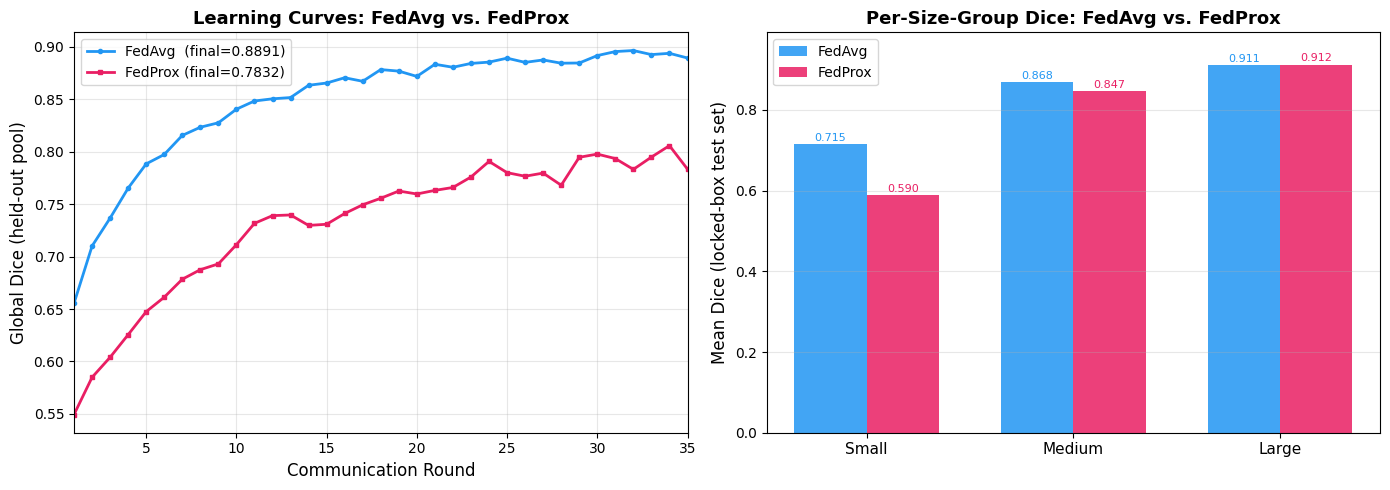

✅ Plot saved → /content/drive/MyDrive/fedprox_v2_checkpoints/fedavg_vs_fedprox_comparison.png


In [33]:
# ── G.1  Learning Curve: Round vs. Global Dice ───────────────────────────────
#
# Both curves use the identical held-out eval pool (50 cases) evaluated after
# every round during training, so they are directly comparable.
#
# Shaded region shows ±1 std across the 50 per-case Dice scores at round 35
# (final round only) to indicate score spread without cluttering the plot.

fa_df = pd.DataFrame(fedavg_round_scores)
fp_df = pd.DataFrame(round_scores_fp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: Convergence curves ───────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(
    fa_df["round"], fa_df["global_dice"],
    label=f"FedAvg  (final={fa_df['global_dice'].iloc[-1]:.4f})",
    color='#2196F3', marker='o', markersize=3, linewidth=2
)
ax1.plot(
    fp_df["round"], fp_df["global_dice"],
    label=f"FedProx (final={fp_df['global_dice'].iloc[-1]:.4f})",
    color='#E91E63', marker='s', markersize=3, linewidth=2
)
ax1.set_xlabel("Communication Round", fontsize=12)
ax1.set_ylabel("Global Dice (held-out pool)", fontsize=12)
ax1.set_title("Learning Curves: FedAvg vs. FedProx", fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1, max(ROUNDS_FP, len(fa_df)))

# ── Panel 2: Per-size-group Dice bar chart ────────────────────────────────────
ax2    = axes[1]
groups = ["small", "medium", "large"]
x      = np.arange(len(groups))
width  = 0.35

fa_grp  = results_fedavg.groupby("size_group")["dice"].mean()
fp_grp  = results_fedprox.groupby("size_group")["dice"].mean()

fa_vals = [fa_grp.get(g, 0) for g in groups]
fp_vals = [fp_grp.get(g, 0) for g in groups]

bars_fa = ax2.bar(x - width/2, fa_vals, width, label='FedAvg',  color='#2196F3', alpha=0.85)
bars_fp = ax2.bar(x + width/2, fp_vals, width, label='FedProx', color='#E91E63', alpha=0.85)

# Annotate bar values
for bar in bars_fa:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=8, color='#2196F3')
for bar in bars_fp:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=8, color='#E91E63')

ax2.set_xticks(x)
ax2.set_xticklabels([g.capitalize() for g in groups], fontsize=11)
ax2.set_ylabel("Mean Dice (locked-box test set)", fontsize=12)
ax2.set_title("Per-Size-Group Dice: FedAvg vs. FedProx", fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, min(1.0, max(fa_vals + fp_vals) + 0.08))

plt.tight_layout()
out_path = FEDPROX_CKPT_DIR / 'fedavg_vs_fedprox_comparison.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Plot saved → {out_path}")

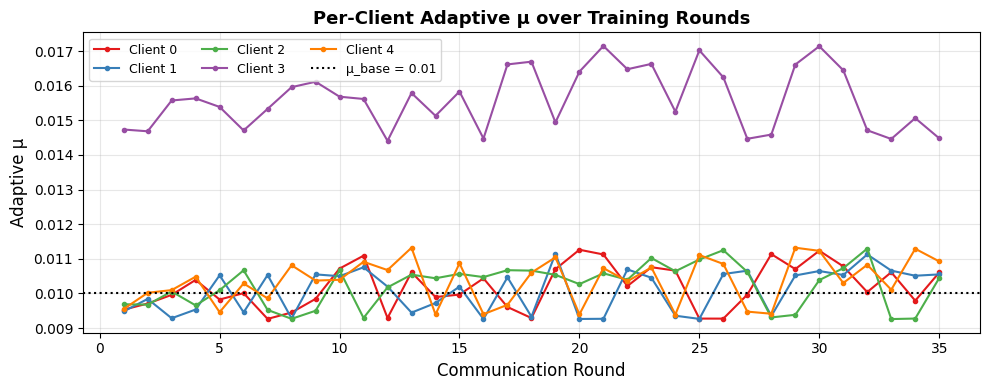

✅ μ analysis plot saved → /content/drive/MyDrive/fedprox_v2_checkpoints/adaptive_mu_per_client.png

Per-client μ summary (across all rounds):
             mu          alpha_size      alpha_var         
           mean      std       mean  std      mean      std
client                                                     
0       0.01020  0.00063     0.9257  0.0   1.10202  0.06820
1       0.01008  0.00063     0.9257  0.0   1.08935  0.06783
2       0.01023  0.00061     0.9257  0.0   1.10501  0.06566
3       0.01561  0.00087     1.4400  0.0   1.08416  0.06073
4       0.01036  0.00065     0.9391  0.0   1.10352  0.06919


In [34]:
# ── G.2  Adaptive μ Analysis ─────────────────────────────────────────────────
#
# Visualise how μ evolved per client over training rounds.
# High inter-client variance confirms that the adaptive scheme is doing work;
# convergence of μ across rounds indicates the model is stabilising.

mu_records = []
for rnd_entry in mu_log_all:
    for c_info in rnd_entry["clients"]:
        mu_records.append({"round": rnd_entry["round"], **c_info})
mu_df = pd.DataFrame(mu_records)

if not mu_df.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
    for i in range(5):
        c_df = mu_df[mu_df["client"] == i]
        ax.plot(c_df["round"], c_df["mu"],
                label=f"Client {i}", color=colors[i], marker='o', markersize=3)
    ax.axhline(MU_BASE, color='black', linestyle=':', linewidth=1.5,
               label=f'μ_base = {MU_BASE}')
    ax.set_xlabel("Communication Round", fontsize=12)
    ax.set_ylabel("Adaptive μ", fontsize=12)
    ax.set_title("Per-Client Adaptive μ over Training Rounds", fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, ncol=3)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    mu_plot_path = FEDPROX_CKPT_DIR / 'adaptive_mu_per_client.png'
    plt.savefig(mu_plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ μ analysis plot saved → {mu_plot_path}")

    print("\nPer-client μ summary (across all rounds):")
    print(mu_df.groupby("client")[["mu", "alpha_size", "alpha_var"]]
          .agg(["mean", "std"])
          .round(5)
          .to_string())
else:
    print("μ log is empty — run Section C first.")

In [36]:
# ── G.3  Final Printed Summary ───────────────────────────────────────────────
# All numbers come from results_fedavg and results_fedprox — both are
# DataFrames produced by eval_on_locked_box() in F.1, with columns:
#   case | dice | size_group | lesion_cm3
# No other variable sources are used.

def _delta_str(a, b):
    d = a - b
    return f"{'+'if d>=0 else ''}{d:.4f}"

# ── Per-client is not available on the locked-box test set (cases were drawn
#    before client assignment), so we report per-size-group as the fairness
#    proxy — consistent with the locked-box design in FEDAVG_FEDPROX_COMPLETE.

fa_by_group = results_fedavg.groupby("size_group")["dice"].mean()
fp_by_group = results_fedprox.groupby("size_group")["dice"].mean()

fa_mean  = results_fedavg["dice"].mean()
fp_mean  = results_fedprox["dice"].mean()
fa_small = fa_by_group.get("small",  float("nan"))
fp_small = fp_by_group.get("small",  float("nan"))
fa_med   = fa_by_group.get("medium", float("nan"))
fp_med   = fp_by_group.get("medium", float("nan"))
fa_large = fa_by_group.get("large",  float("nan"))
fp_large = fp_by_group.get("large",  float("nan"))
fa_worst = fa_by_group.min()
fp_worst = fp_by_group.min()
fa_worst_grp = fa_by_group.idxmin()
fp_worst_grp = fp_by_group.idxmin()

print("\n" + "═" * 68)
print("  RESEARCH SUMMARY — FedAvg vs. FedProx (Locked-Box Test Set, 90 cases)")
print("═" * 68)
print(f"\n  {'Metric':<26} {'FedAvg':>8}  {'FedProx':>8}  {'Δ':>8}")
print(f"  {'─'*54}")
print(f"  {'Mean Dice':<26} {fa_mean:>8.4f}  {fp_mean:>8.4f}  {_delta_str(fp_mean, fa_mean):>8}")
print(f"  {'Small-Lesion Dice':<26} {fa_small:>8.4f}  {fp_small:>8.4f}  {_delta_str(fp_small, fa_small):>8}")
print(f"  {'Medium-Lesion Dice':<26} {fa_med:>8.4f}  {fp_med:>8.4f}  {_delta_str(fp_med, fa_med):>8}")
print(f"  {'Large-Lesion Dice':<26} {fa_large:>8.4f}  {fp_large:>8.4f}  {_delta_str(fp_large, fa_large):>8}")
print(f"  {'─'*54}")
print(f"  {'Worst-Group Dice':<26} {fa_worst:>8.4f}  {fp_worst:>8.4f}  {_delta_str(fp_worst, fa_worst):>8}")
print(f"  {'  (worst group)':<26} {'['+fa_worst_grp+']':>8}   {'['+fp_worst_grp+']':>8}")
print(f"  {'Fairness Gap (Mean−Worst)':<26} {fa_mean-fa_worst:>8.4f}  {fp_mean-fp_worst:>8.4f}  {_delta_str(fp_mean-fp_worst, fa_mean-fa_worst):>8}")
print()
print(f"  Notes:")
print(f"    • Eval set : locked-box, 30 small / 30 medium / 30 large")
print(f"    • FedProx  : μ_base={MU_BASE}, adaptive (size × loss-var scaling)")
print(f"    • Both     : 35 rounds × 5 local epochs, 5 clients, Adam lr=1e-4")
print(f"    • Positive Δ = FedProx improvement over FedAvg")
print("═" * 68)


════════════════════════════════════════════════════════════════════
  RESEARCH SUMMARY — FedAvg vs. FedProx (Locked-Box Test Set, 90 cases)
════════════════════════════════════════════════════════════════════

  Metric                       FedAvg   FedProx         Δ
  ──────────────────────────────────────────────────────
  Mean Dice                    0.8314    0.7832   -0.0482
  Small-Lesion Dice            0.7147    0.5899   -0.1249
  Medium-Lesion Dice           0.8684    0.8475   -0.0209
  Large-Lesion Dice            0.9110    0.9124   +0.0013
  ──────────────────────────────────────────────────────
  Worst-Group Dice             0.7147    0.5899   -0.1249
    (worst group)             [small]    [small]
  Fairness Gap (Mean−Worst)    0.1167    0.1934   +0.0767

  Notes:
    • Eval set : locked-box, 30 small / 30 medium / 30 large
    • FedProx  : μ_base=0.01, adaptive (size × loss-var scaling)
    • Both     : 35 rounds × 5 local epochs, 5 clients, Adam lr=1e-4
    • Positive